In [1]:
# Function definitions and imports for batch processing all folders
import os
import re
import cv2
import numpy as np
from datetime import datetime, timedelta
from scipy.signal import find_peaks, peak_widths
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import glob
import pandas as pd

# Parameters (CHANGE)
# parent_folder = "/Volumes/D06V1/D06V1/OSC_Videos/2026ab/"
parent_folder = "/Volumes/Untitled/"
peak_threshold = 3.5  # V, for peak detection in Vpp signal
profile_threshold_stored = 1000  # Threshold for stored region
profile_threshold_inj = 1000     # Threshold for inj region
# max_files = 2  # Set to a number to limit files per folder, or None to process all
max_files = None  # Uncomment to process all files

# Parameters (DO NOT CHANGE)
grid_height_px_stored = 3.4/5.56*400/10/1.05  # stored region (distorted)
grid_height_px_inj = 3.95/5.56*400/10         # inj region
inj_time_px = 30
v_div = 2.0
fps = 20.0

def extract_datetime_from_filename(filename):
    """Extract YYYYMMDD_HHMMSS from filename."""
    match = re.search(r"(\d{8})_(\d{6})", filename)
    if not match:
        return None
    date_part, time_part = match.groups()
    return datetime.strptime(date_part + time_part, "%Y%m%d%H%M%S")

def _vpp_from_mask(mask_part, threshold, volts_per_pixel):
    """Compute Vpp from mask using profile + threshold method."""
    vertical_profile = np.sum(mask_part, axis=1)
    smooth_profile = gaussian_filter1d(vertical_profile.astype(float), sigma=2.0)
    above_threshold = smooth_profile > threshold
    if np.any(above_threshold):
        threshold_positions = np.where(above_threshold)[0]
        y_min = threshold_positions[0]
        y_max = threshold_positions[-1]
        peak_width_pixels = y_max - y_min
        return peak_width_pixels * volts_per_pixel
    return np.nan

def compute_vpp_series_for_file(file_path, v_div=2.0, fps=20.0, threshold_stored=1000, threshold_inj=1000, split_x=None, grid_height_px_stored=3.4/5.56*400/10/1.05, grid_height_px_inj=3.95/5.56*400/10):
    """Compute Vpp for CH3 (red trace) per frame for both stored and inj regions."""
    cap = cv2.VideoCapture(file_path)
    volts_per_pixel_stored = v_div / grid_height_px_stored
    volts_per_pixel_inj = v_div / grid_height_px_inj

    vpp_stored_series = []
    vpp_inj_series = []

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        height, width, _ = frame.shape
        roi = frame[int(height * 0.2):int(height * 0.8), int(width * 0.1):int(width * 0.9)]

        hsv = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)
        mask1 = cv2.inRange(hsv, np.array([0, 100, 100]), np.array([10, 255, 255]))
        mask2 = cv2.inRange(hsv, np.array([160, 100, 100]), np.array([180, 255, 255]))
        red_mask = cv2.bitwise_or(mask1, mask2)

        split_idx = max(0, min(int(split_x), red_mask.shape[1] - 1))
        red_mask_stored = red_mask[:, :split_idx + 1]
        red_mask_inj = red_mask[:, split_idx + 1:]

        if red_mask_stored.shape[1] > 0:
            vpp_stored_series.append(_vpp_from_mask(red_mask_stored, threshold_stored, volts_per_pixel_stored))
        else:
            vpp_stored_series.append(np.nan)

        if red_mask_inj.shape[1] > 0:
            vpp_inj_series.append(_vpp_from_mask(red_mask_inj, threshold_inj, volts_per_pixel_inj))
        else:
            vpp_inj_series.append(np.nan)

    cap.release()
    time_series_sec = np.arange(len(vpp_stored_series)) / fps
    return time_series_sec, np.array(vpp_stored_series), np.array(vpp_inj_series)

Found 12 folder(s) in: /Volumes/Untitled/

[1/12] Processing folder: 20260306
Found 288 total video file(s)
Processing all 288 file(s)

[1/288] 20260306_000000_n.mkv
  ✓ Vpp_stored: 2.318 - 3.692 V
  ✓ Vpp_inj: 2.674 - 3.871 V

[2/288] 20260306_000500_n.mkv
  ✓ Vpp_stored: 2.661 - 3.778 V
  ✓ Vpp_inj: 2.886 - 3.941 V

[3/288] 20260306_001000_n.mkv
  ✓ Vpp_stored: 2.576 - 3.606 V
  ✓ Vpp_inj: 2.745 - 3.801 V

[4/288] 20260306_001500_n.mkv
  ✓ Vpp_stored: 2.576 - 3.434 V
  ✓ Vpp_inj: 2.745 - 3.660 V

[5/288] 20260306_002000_n.mkv
  ✓ Vpp_stored: 2.146 - 3.262 V
  ✓ Vpp_inj: 2.463 - 3.660 V

[6/288] 20260306_002500_n.mkv
  ✓ Vpp_stored: 2.318 - 3.520 V
  ✓ Vpp_inj: 2.534 - 3.660 V

[7/288] 20260306_003000_n.mkv
  ✓ Vpp_stored: 2.404 - 3.348 V
  ✓ Vpp_inj: 2.674 - 3.589 V

[8/288] 20260306_003500_n.mkv
  ✓ Vpp_stored: 2.490 - 3.262 V
  ✓ Vpp_inj: 2.674 - 3.519 V

[9/288] 20260306_004000_n.mkv
  ✓ Vpp_stored: 2.747 - 3.606 V
  ✓ Vpp_inj: 2.956 - 3.660 V

[10/288] 20260306_004500_n.mkv
  ✓ V

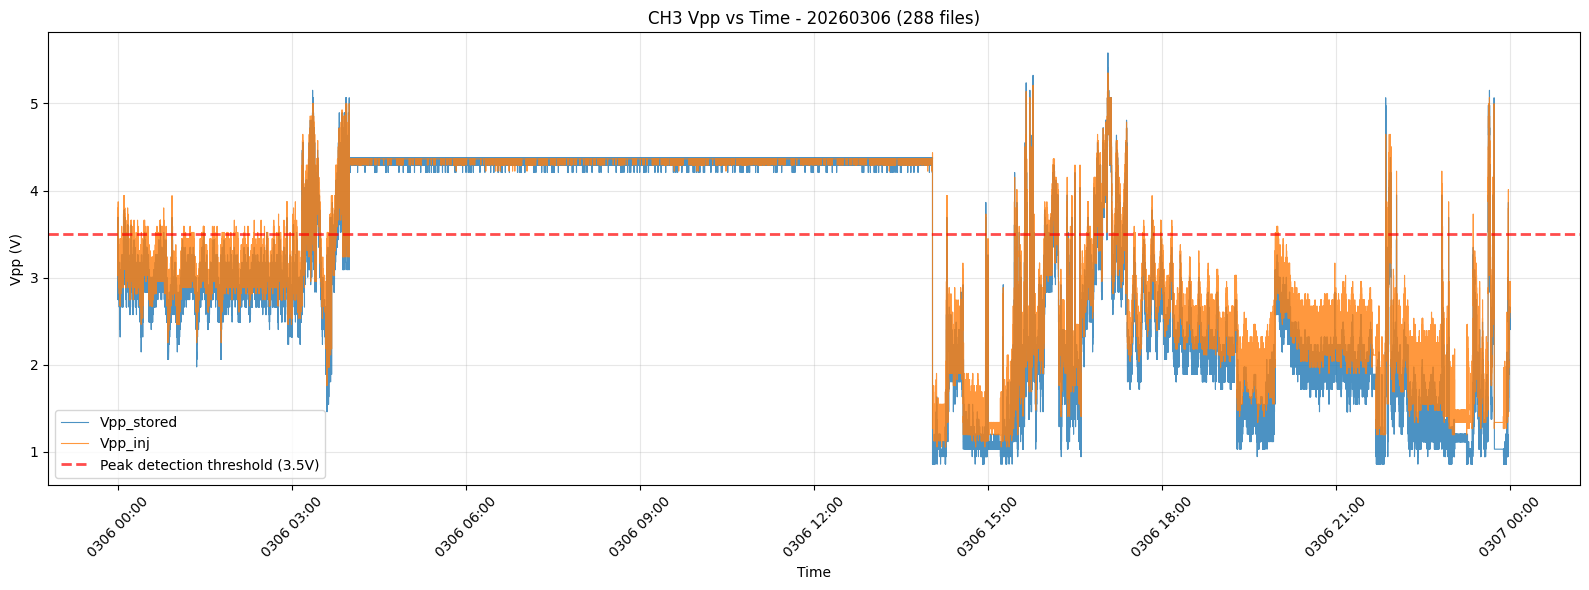


Found 13708 STORED peaks with Vpp > 3.5 V
Found 4538 INJ peaks with Vpp > 3.5 V


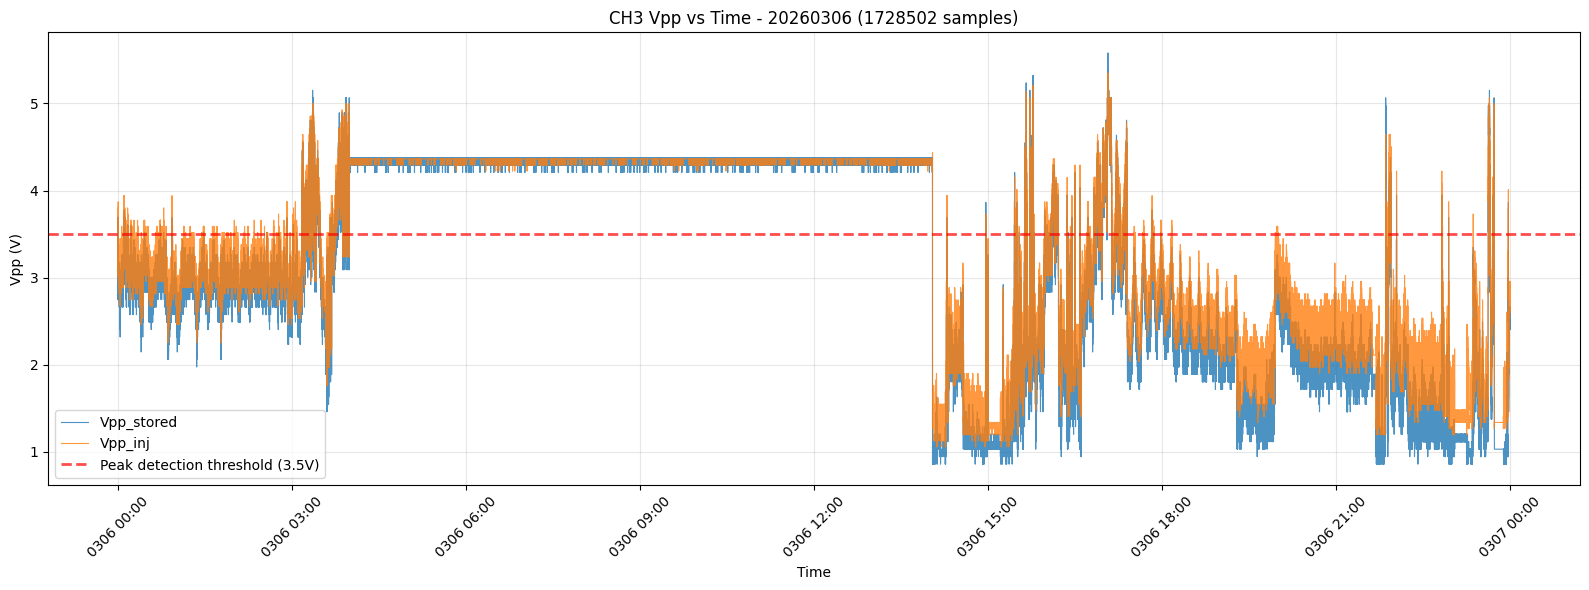

✓ Peak summary plot saved to: /Users/xylu/Desktop/Data/acoustic_vpp/summary/20260306_peak_summary_plot.png
✓ Stored peaks saved to: /Users/xylu/Desktop/Data/acoustic_vpp/summary/20260306_peaks_stored.csv
✓ Inj peaks saved to: /Users/xylu/Desktop/Data/acoustic_vpp/summary/20260306_peaks_inj.csv

✓ Folder '20260306' complete! Data saved to: /Users/xylu/Desktop/Data/acoustic_vpp/20260306

[2/12] Processing folder: 20260307
Found 288 total video file(s)
Processing all 288 file(s)

[1/288] 20260307_000000_n.mkv
  ✓ Vpp_stored: 0.944 - 2.576 V
  ✓ Vpp_inj: 1.267 - 2.886 V

[2/288] 20260307_000500_n.mkv
  ✓ Vpp_stored: 0.859 - 3.348 V
  ✓ Vpp_inj: 1.196 - 3.660 V

[3/288] 20260307_001000_n.mkv
  ✓ Vpp_stored: 0.944 - 3.520 V
  ✓ Vpp_inj: 1.337 - 3.801 V

[4/288] 20260307_001500_n.mkv
  ✓ Vpp_stored: 1.975 - 5.409 V
  ✓ Vpp_inj: 2.323 - 5.278 V

[5/288] 20260307_002000_n.mkv
  ✓ Vpp_stored: 0.859 - 2.919 V
  ✓ Vpp_inj: 1.196 - 3.097 V

[6/288] 20260307_002500_n.mkv
  ✓ Vpp_stored: 0.859 - 4.55

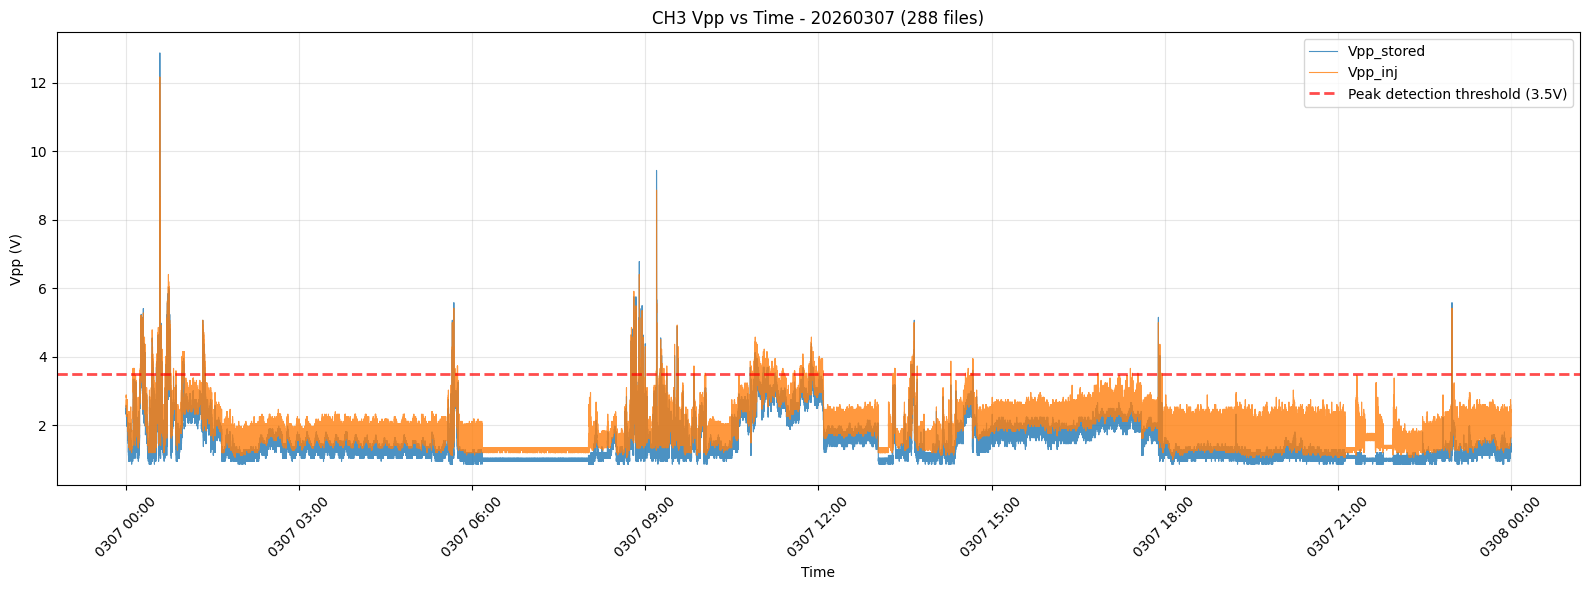


Found 705 STORED peaks with Vpp > 3.5 V
Found 1468 INJ peaks with Vpp > 3.5 V


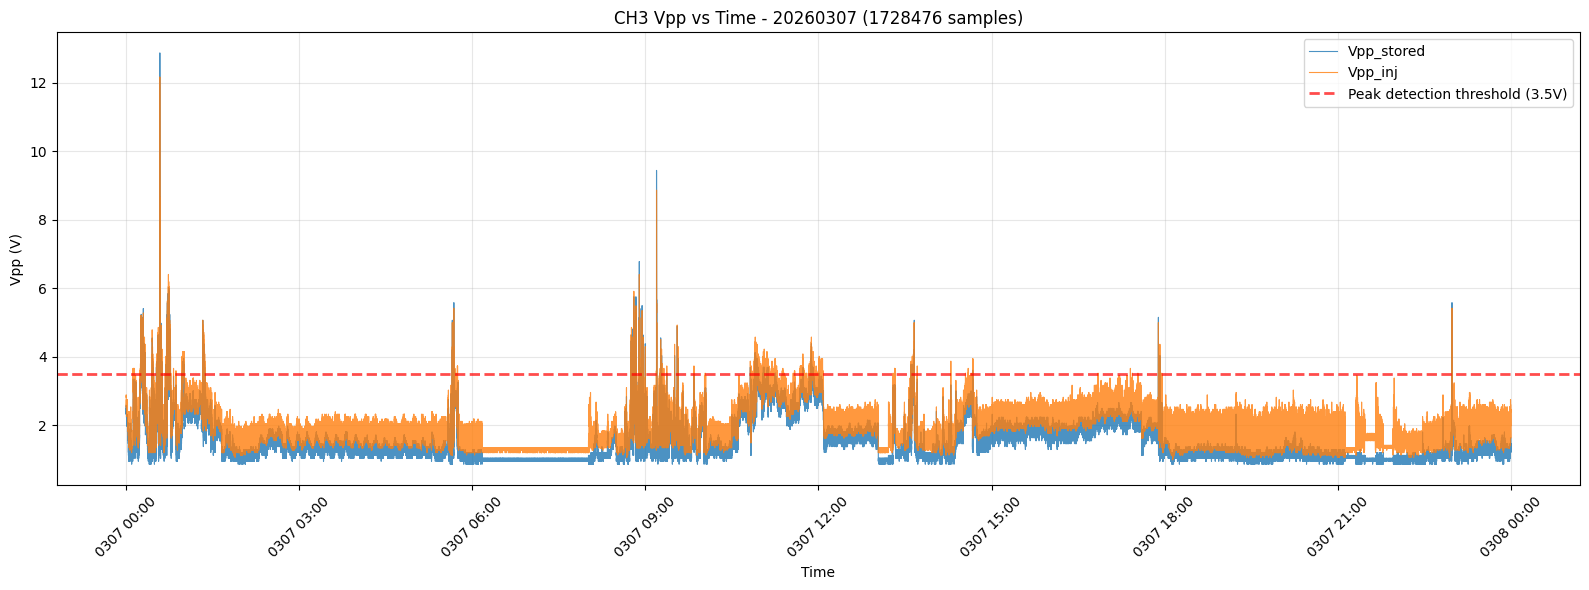

✓ Peak summary plot saved to: /Users/xylu/Desktop/Data/acoustic_vpp/summary/20260307_peak_summary_plot.png
✓ Stored peaks saved to: /Users/xylu/Desktop/Data/acoustic_vpp/summary/20260307_peaks_stored.csv
✓ Inj peaks saved to: /Users/xylu/Desktop/Data/acoustic_vpp/summary/20260307_peaks_inj.csv

✓ Folder '20260307' complete! Data saved to: /Users/xylu/Desktop/Data/acoustic_vpp/20260307

[3/12] Processing folder: 20260308
Found 288 total video file(s)
Processing all 288 file(s)

[1/288] 20260308_000000_n.mkv
  ✓ Vpp_stored: 0.944 - 1.975 V
  ✓ Vpp_inj: 1.337 - 2.886 V

[2/288] 20260308_000500_n.mkv
  ✓ Vpp_stored: 0.944 - 1.631 V
  ✓ Vpp_inj: 1.337 - 2.604 V

[3/288] 20260308_001000_n.mkv
  ✓ Vpp_stored: 1.030 - 2.146 V
  ✓ Vpp_inj: 1.337 - 2.815 V

[4/288] 20260308_001500_n.mkv
  ✓ Vpp_stored: 0.944 - 1.545 V
  ✓ Vpp_inj: 1.337 - 2.534 V

[5/288] 20260308_002000_n.mkv
  ✓ Vpp_stored: 0.944 - 2.232 V
  ✓ Vpp_inj: 1.267 - 2.956 V

[6/288] 20260308_002500_n.mkv
  ✓ Vpp_stored: 1.030 - 1.88

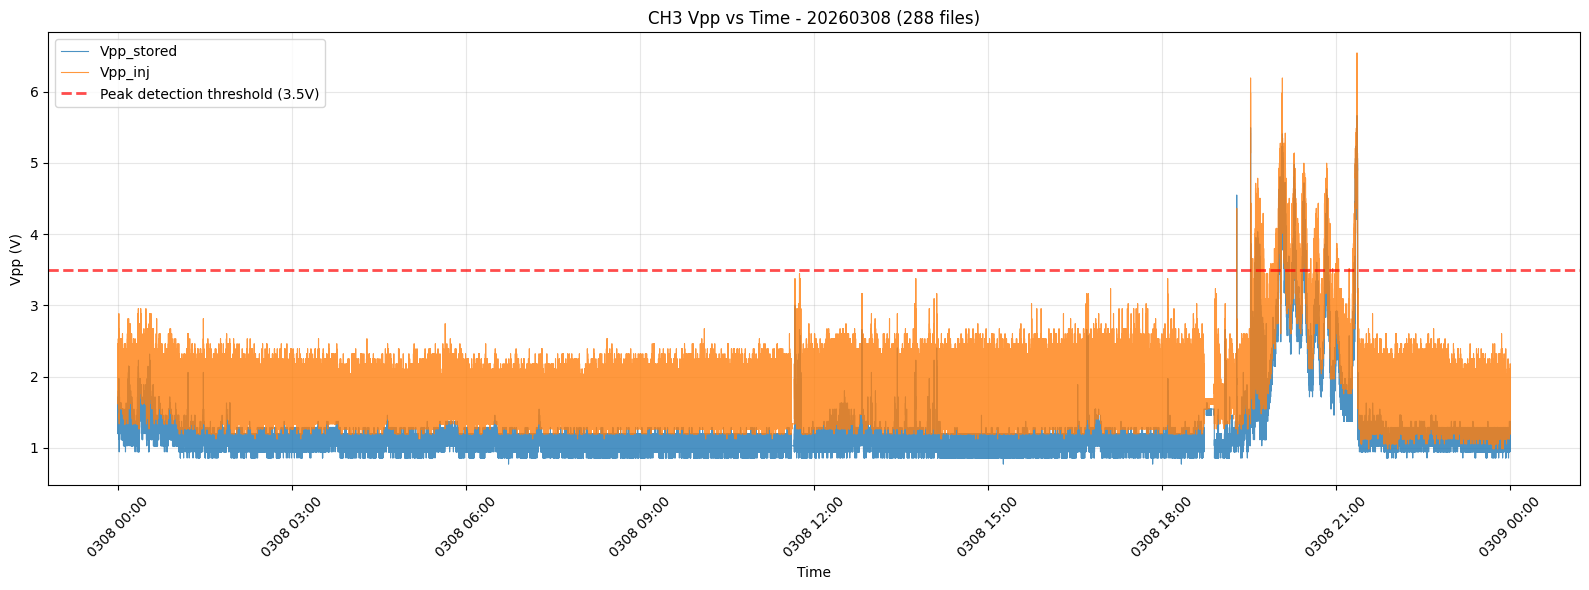


Found 722 STORED peaks with Vpp > 3.5 V
Found 1464 INJ peaks with Vpp > 3.5 V


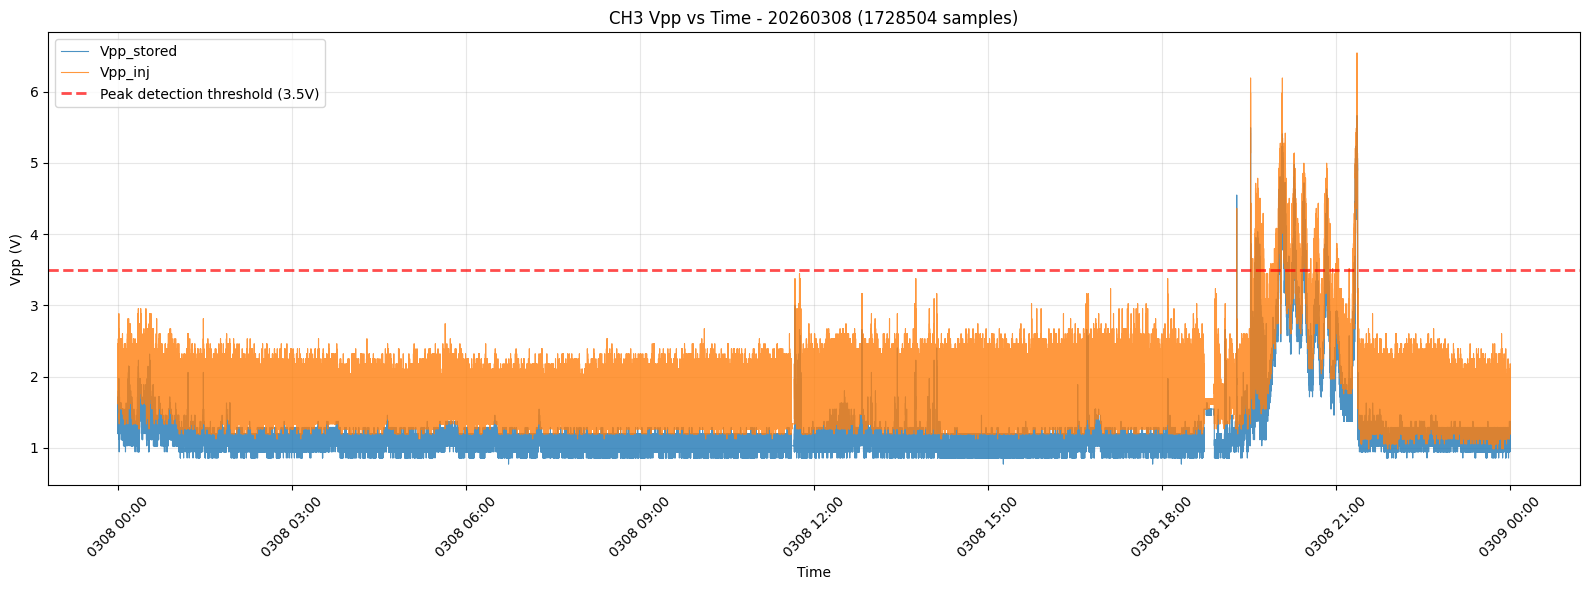

✓ Peak summary plot saved to: /Users/xylu/Desktop/Data/acoustic_vpp/summary/20260308_peak_summary_plot.png
✓ Stored peaks saved to: /Users/xylu/Desktop/Data/acoustic_vpp/summary/20260308_peaks_stored.csv
✓ Inj peaks saved to: /Users/xylu/Desktop/Data/acoustic_vpp/summary/20260308_peaks_inj.csv

✓ Folder '20260308' complete! Data saved to: /Users/xylu/Desktop/Data/acoustic_vpp/20260308

[4/12] Processing folder: 20260309
Found 288 total video file(s)
Processing all 288 file(s)

[1/288] 20260309_000000_n.mkv
  ✓ Vpp_stored: 0.944 - 1.374 V
  ✓ Vpp_inj: 1.196 - 2.323 V

[2/288] 20260309_000500_n.mkv
  ✓ Vpp_stored: 0.944 - 1.374 V
  ✓ Vpp_inj: 1.126 - 2.182 V

[3/288] 20260309_001000_n.mkv
  ✓ Vpp_stored: 0.859 - 1.288 V
  ✓ Vpp_inj: 1.126 - 2.182 V

[4/288] 20260309_001500_n.mkv
  ✓ Vpp_stored: 0.944 - 1.288 V
  ✓ Vpp_inj: 1.056 - 2.252 V

[5/288] 20260309_002000_n.mkv
  ✓ Vpp_stored: 0.944 - 1.374 V
  ✓ Vpp_inj: 1.056 - 2.252 V

[6/288] 20260309_002500_n.mkv
  ✓ Vpp_stored: 0.944 - 1.46

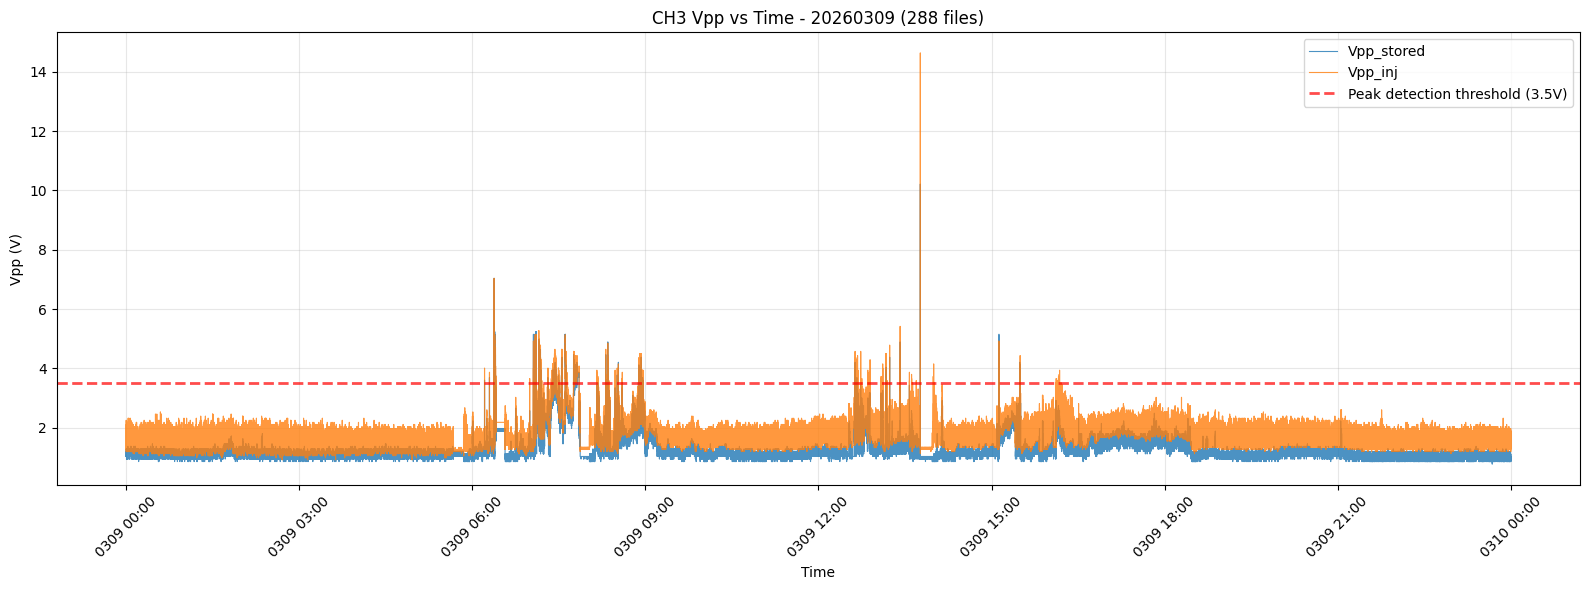


Found 443 STORED peaks with Vpp > 3.5 V
Found 667 INJ peaks with Vpp > 3.5 V


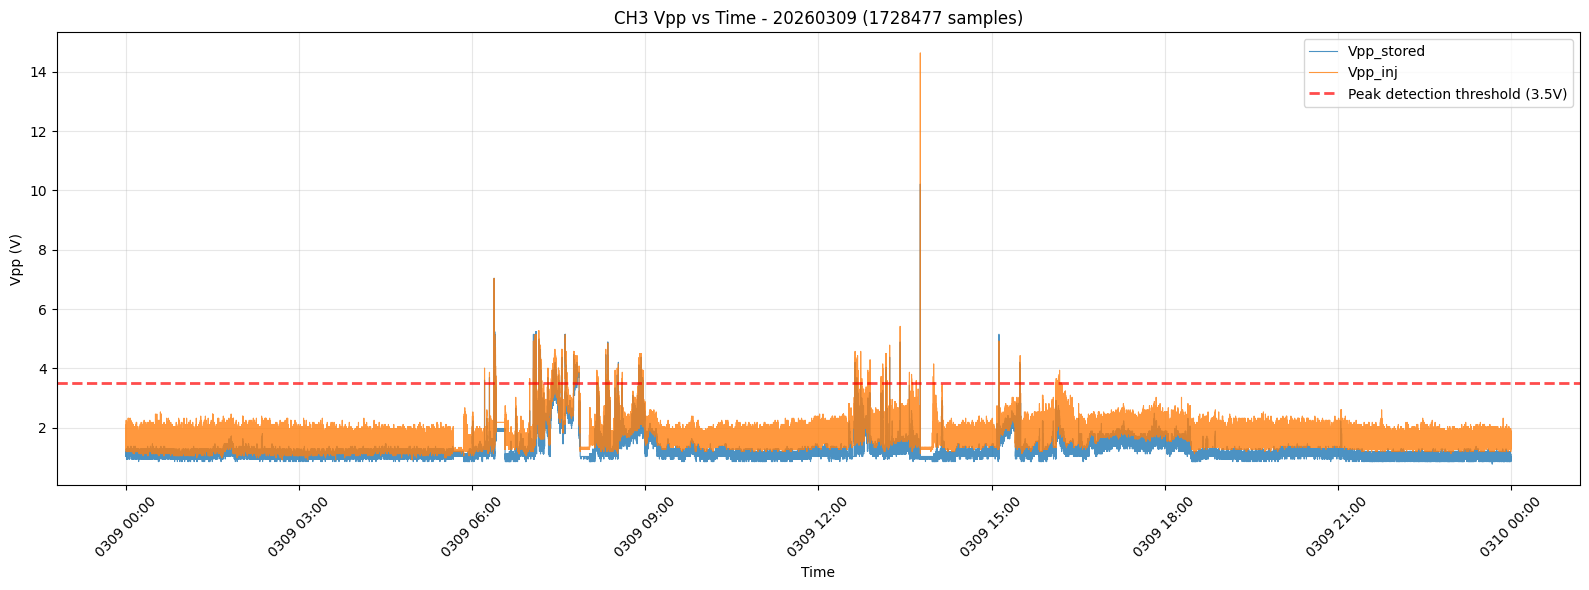

✓ Peak summary plot saved to: /Users/xylu/Desktop/Data/acoustic_vpp/summary/20260309_peak_summary_plot.png
✓ Stored peaks saved to: /Users/xylu/Desktop/Data/acoustic_vpp/summary/20260309_peaks_stored.csv
✓ Inj peaks saved to: /Users/xylu/Desktop/Data/acoustic_vpp/summary/20260309_peaks_inj.csv

✓ Folder '20260309' complete! Data saved to: /Users/xylu/Desktop/Data/acoustic_vpp/20260309

[5/12] Processing folder: 20260310
Found 288 total video file(s)
Processing all 288 file(s)

[1/288] 20260310_000000_n.mkv
  ✓ Vpp_stored: 0.859 - 1.288 V
  ✓ Vpp_inj: 1.126 - 2.041 V

[2/288] 20260310_000500_n.mkv
  ✓ Vpp_stored: 0.859 - 1.288 V
  ✓ Vpp_inj: 1.196 - 2.111 V

[3/288] 20260310_001000_n.mkv
  ✓ Vpp_stored: 0.859 - 1.288 V
  ✓ Vpp_inj: 1.196 - 2.182 V

[4/288] 20260310_001500_n.mkv
  ✓ Vpp_stored: 0.859 - 1.288 V
  ✓ Vpp_inj: 1.196 - 2.111 V

[5/288] 20260310_002000_n.mkv
  ✓ Vpp_stored: 0.859 - 1.202 V
  ✓ Vpp_inj: 1.196 - 2.111 V

[6/288] 20260310_002500_n.mkv
  ✓ Vpp_stored: 0.859 - 1.20

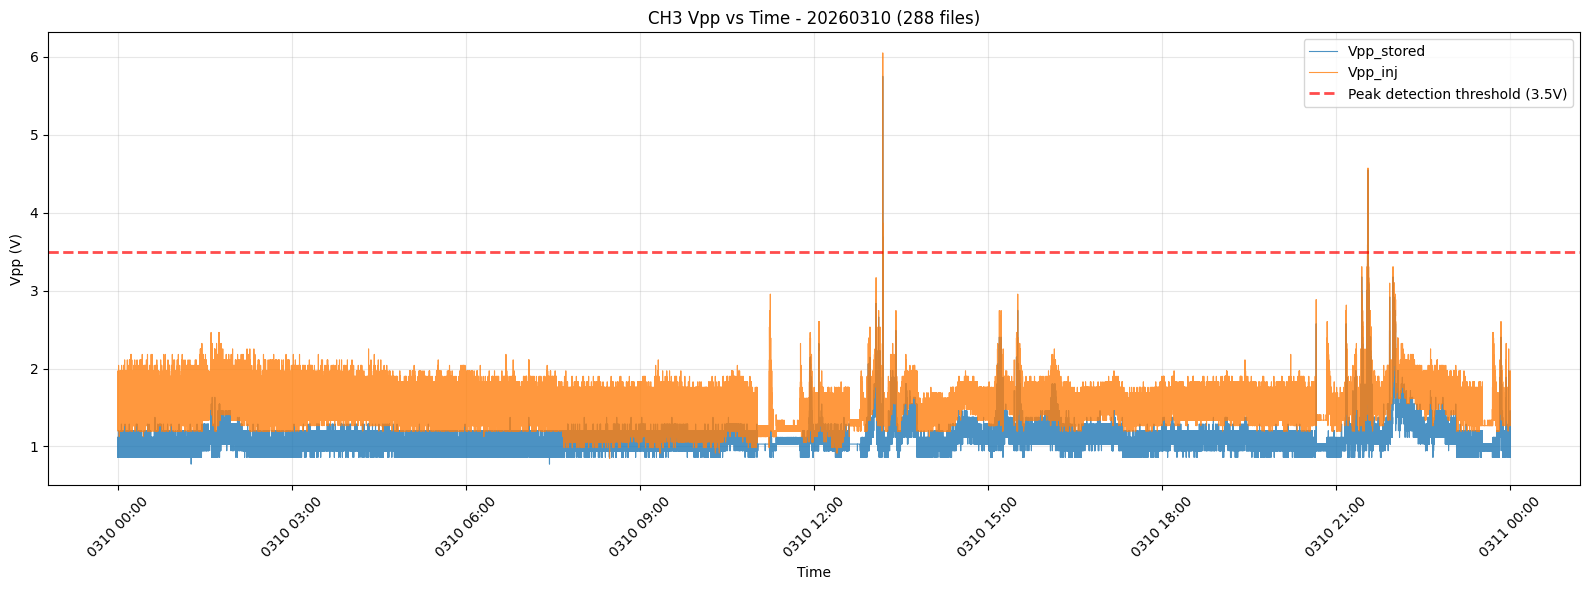


Found 10 STORED peaks with Vpp > 3.5 V
Found 14 INJ peaks with Vpp > 3.5 V


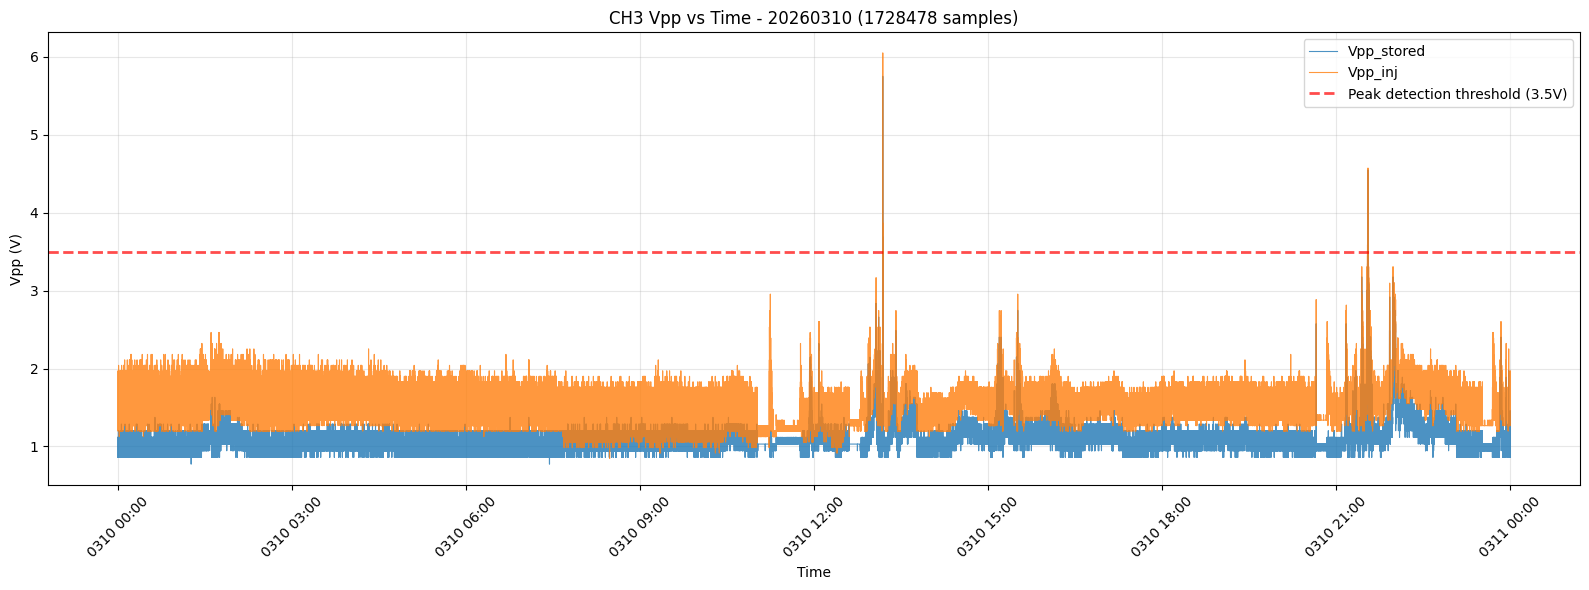

✓ Peak summary plot saved to: /Users/xylu/Desktop/Data/acoustic_vpp/summary/20260310_peak_summary_plot.png
✓ Stored peaks saved to: /Users/xylu/Desktop/Data/acoustic_vpp/summary/20260310_peaks_stored.csv
✓ Inj peaks saved to: /Users/xylu/Desktop/Data/acoustic_vpp/summary/20260310_peaks_inj.csv

✓ Folder '20260310' complete! Data saved to: /Users/xylu/Desktop/Data/acoustic_vpp/20260310

[6/12] Processing folder: 20260311
Found 288 total video file(s)
Processing all 288 file(s)

[1/288] 20260311_000000_n.mkv
  ✓ Vpp_stored: 0.859 - 2.318 V
  ✓ Vpp_inj: 1.267 - 2.745 V

[2/288] 20260311_000500_n.mkv
  ✓ Vpp_stored: 0.944 - 1.717 V
  ✓ Vpp_inj: 1.337 - 2.252 V

[3/288] 20260311_001000_n.mkv
  ✓ Vpp_stored: 1.030 - 1.460 V
  ✓ Vpp_inj: 1.337 - 1.971 V

[4/288] 20260311_001500_n.mkv
  ✓ Vpp_stored: 0.944 - 1.460 V
  ✓ Vpp_inj: 1.267 - 1.900 V

[5/288] 20260311_002000_n.mkv
  ✓ Vpp_stored: 1.030 - 1.545 V
  ✓ Vpp_inj: 1.408 - 2.111 V

[6/288] 20260311_002500_n.mkv
  ✓ Vpp_stored: 0.944 - 1.28

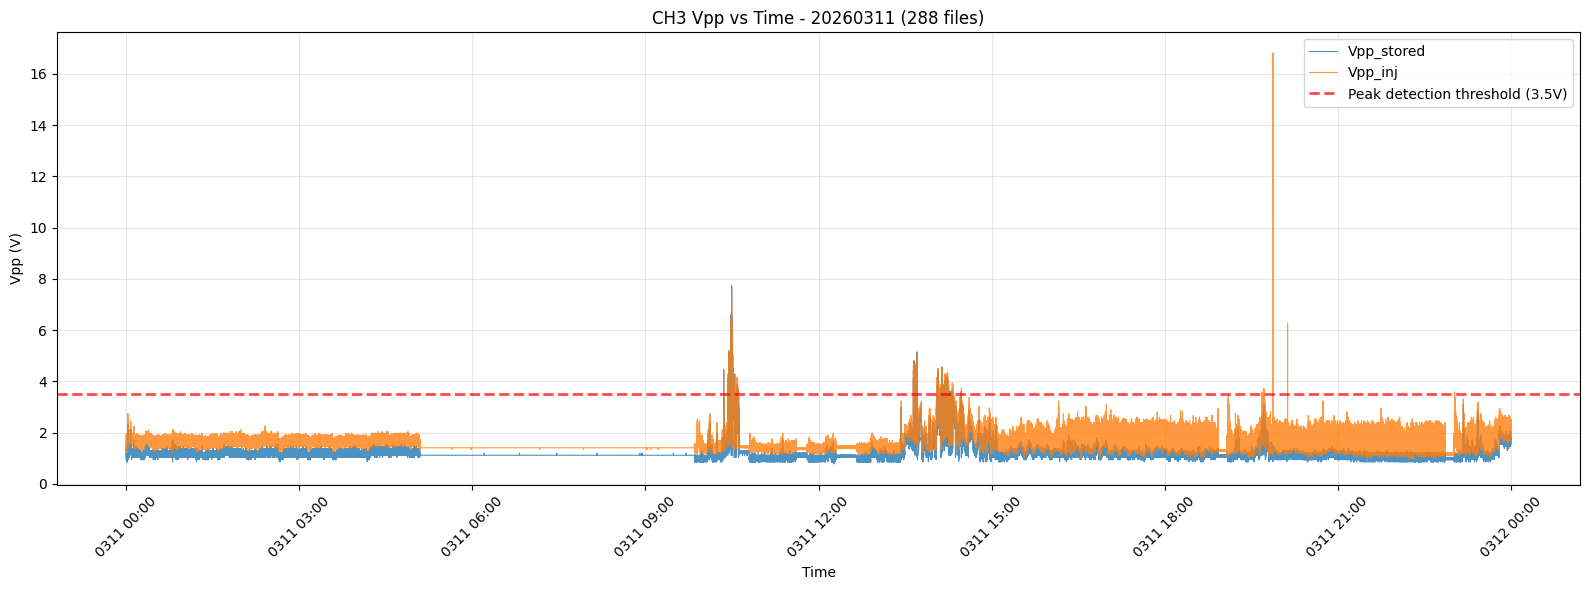


Found 185 STORED peaks with Vpp > 3.5 V
Found 275 INJ peaks with Vpp > 3.5 V


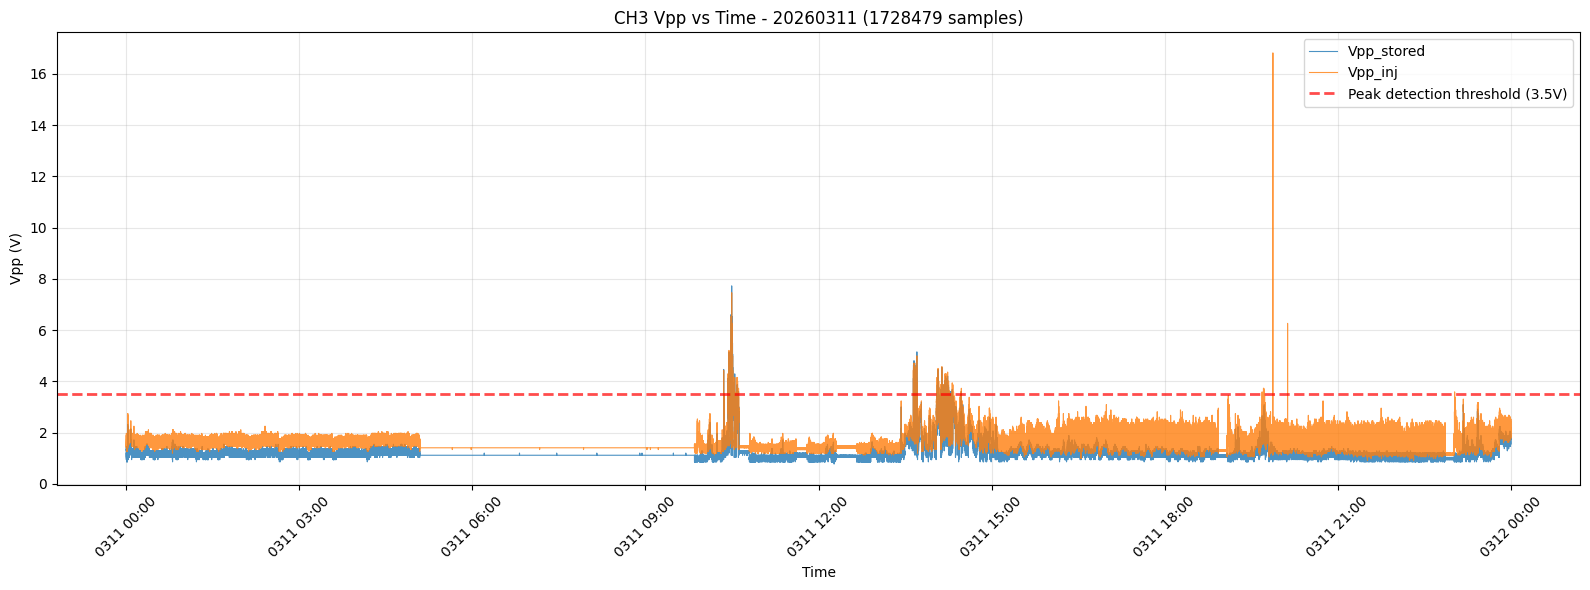

✓ Peak summary plot saved to: /Users/xylu/Desktop/Data/acoustic_vpp/summary/20260311_peak_summary_plot.png
✓ Stored peaks saved to: /Users/xylu/Desktop/Data/acoustic_vpp/summary/20260311_peaks_stored.csv
✓ Inj peaks saved to: /Users/xylu/Desktop/Data/acoustic_vpp/summary/20260311_peaks_inj.csv

✓ Folder '20260311' complete! Data saved to: /Users/xylu/Desktop/Data/acoustic_vpp/20260311

[7/12] Processing folder: 20260312
Found 288 total video file(s)
Processing all 288 file(s)

[1/288] 20260312_000000_n.mkv
  ✓ Vpp_stored: 1.374 - 2.060 V
  ✓ Vpp_inj: 1.689 - 2.745 V

[2/288] 20260312_000500_n.mkv
  ✓ Vpp_stored: 1.288 - 1.889 V
  ✓ Vpp_inj: 1.619 - 2.674 V

[3/288] 20260312_001000_n.mkv
  ✓ Vpp_stored: 1.202 - 1.889 V
  ✓ Vpp_inj: 1.478 - 2.745 V

[4/288] 20260312_001500_n.mkv
  ✓ Vpp_stored: 1.288 - 1.631 V
  ✓ Vpp_inj: 1.619 - 2.393 V

[5/288] 20260312_002000_n.mkv
  ✓ Vpp_stored: 1.545 - 1.631 V
  ✓ Vpp_inj: 1.619 - 1.759 V

[6/288] 20260312_002500_n.mkv
  ✓ Vpp_stored: 1.545 - 1.63

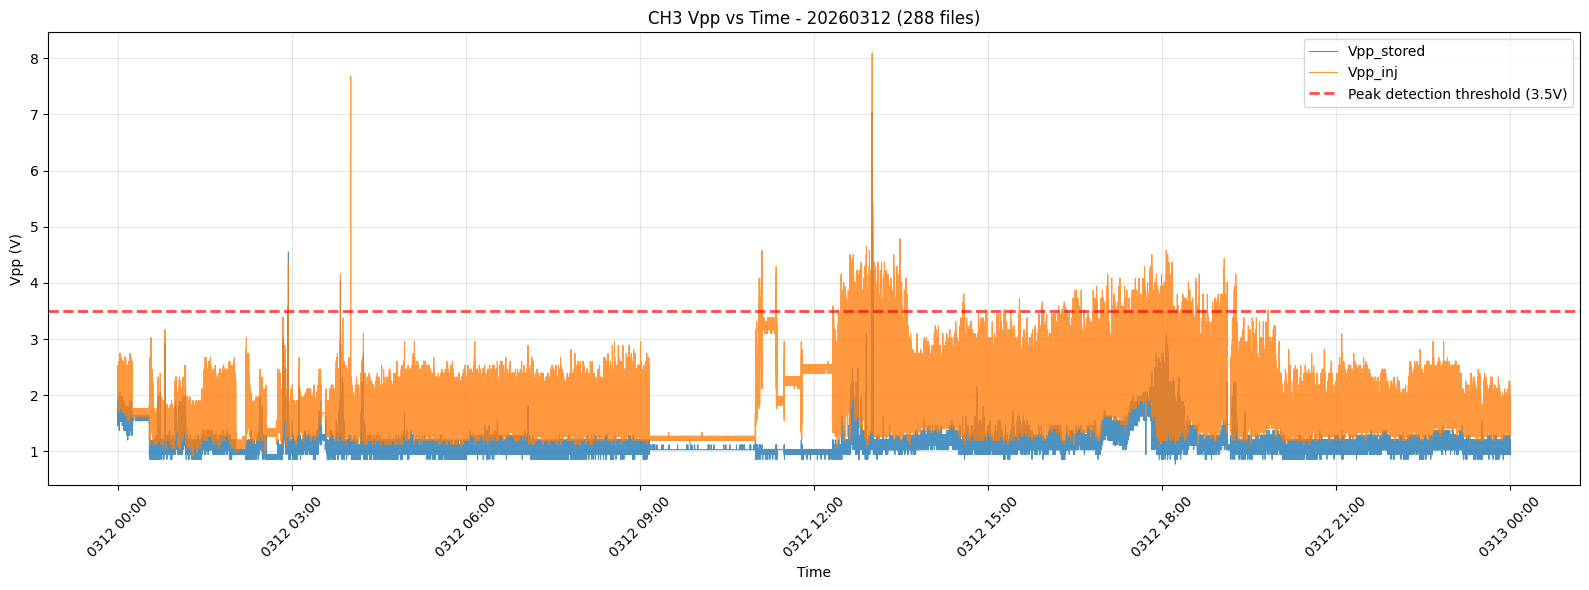


Found 18 STORED peaks with Vpp > 3.5 V
Found 953 INJ peaks with Vpp > 3.5 V


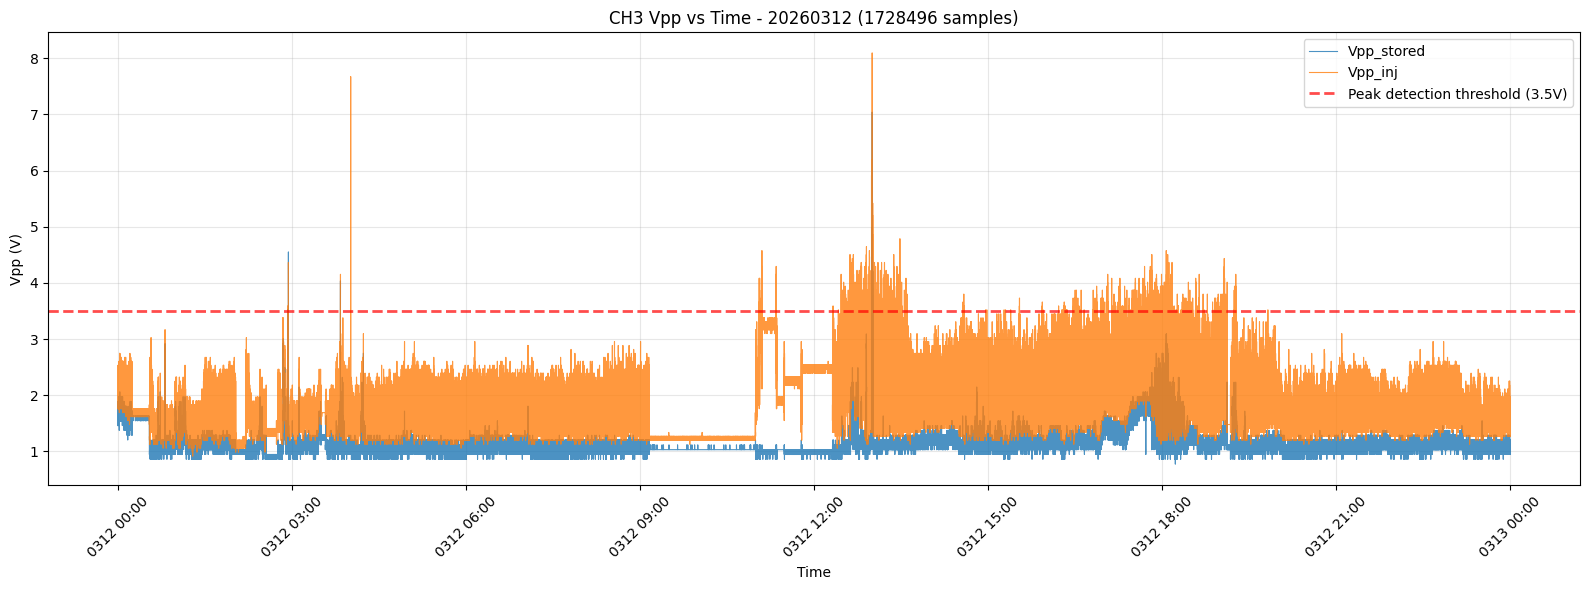

✓ Peak summary plot saved to: /Users/xylu/Desktop/Data/acoustic_vpp/summary/20260312_peak_summary_plot.png
✓ Stored peaks saved to: /Users/xylu/Desktop/Data/acoustic_vpp/summary/20260312_peaks_stored.csv
✓ Inj peaks saved to: /Users/xylu/Desktop/Data/acoustic_vpp/summary/20260312_peaks_inj.csv

✓ Folder '20260312' complete! Data saved to: /Users/xylu/Desktop/Data/acoustic_vpp/20260312

[8/12] Processing folder: 20260313
Found 288 total video file(s)
Processing all 288 file(s)

[1/288] 20260313_000000_n.mkv
  ✓ Vpp_stored: 0.944 - 1.288 V
  ✓ Vpp_inj: 1.267 - 2.111 V

[2/288] 20260313_000500_n.mkv
  ✓ Vpp_stored: 0.859 - 1.288 V
  ✓ Vpp_inj: 1.267 - 2.111 V

[3/288] 20260313_001000_n.mkv
  ✓ Vpp_stored: 0.944 - 1.288 V
  ✓ Vpp_inj: 1.196 - 1.971 V

[4/288] 20260313_001500_n.mkv
  ✓ Vpp_stored: 0.944 - 1.288 V
  ✓ Vpp_inj: 1.196 - 2.041 V

[5/288] 20260313_002000_n.mkv
  ✓ Vpp_stored: 0.859 - 1.288 V
  ✓ Vpp_inj: 1.267 - 1.971 V

[6/288] 20260313_002500_n.mkv
  ✓ Vpp_stored: 0.944 - 1.28

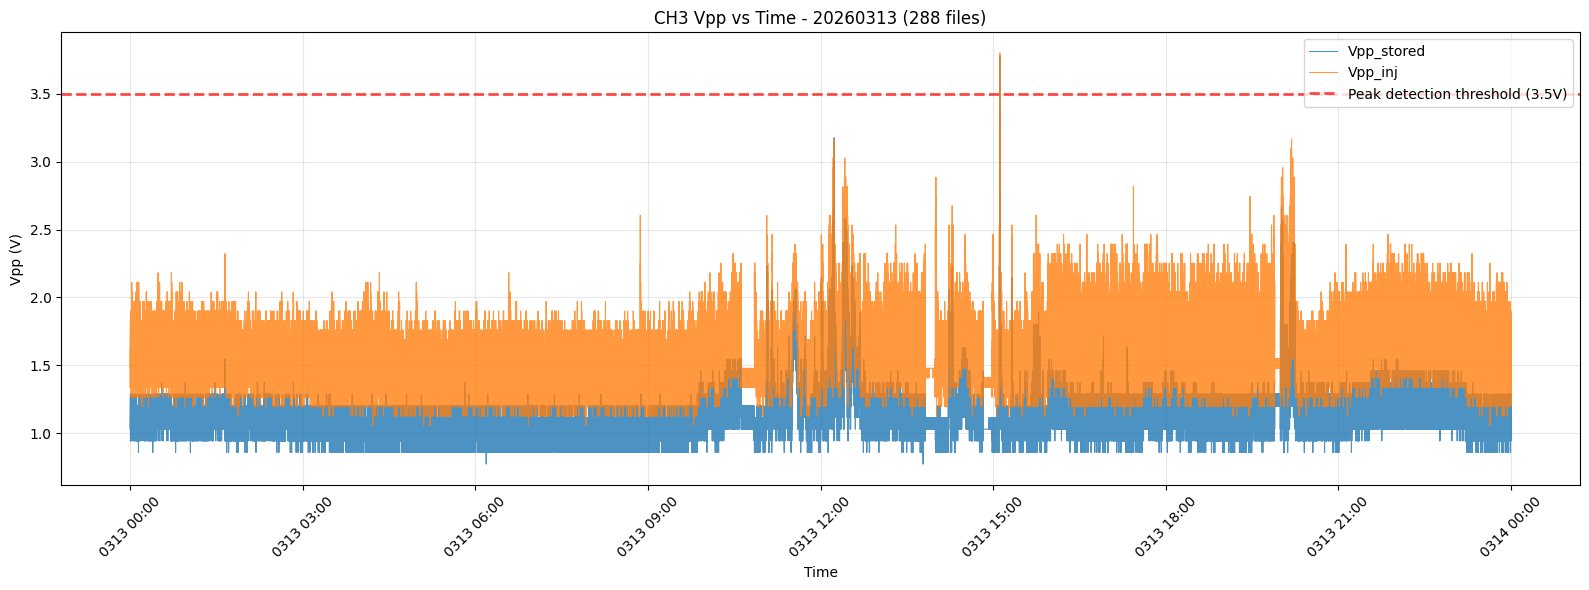


Found 1 STORED peaks with Vpp > 3.5 V
Found 2 INJ peaks with Vpp > 3.5 V


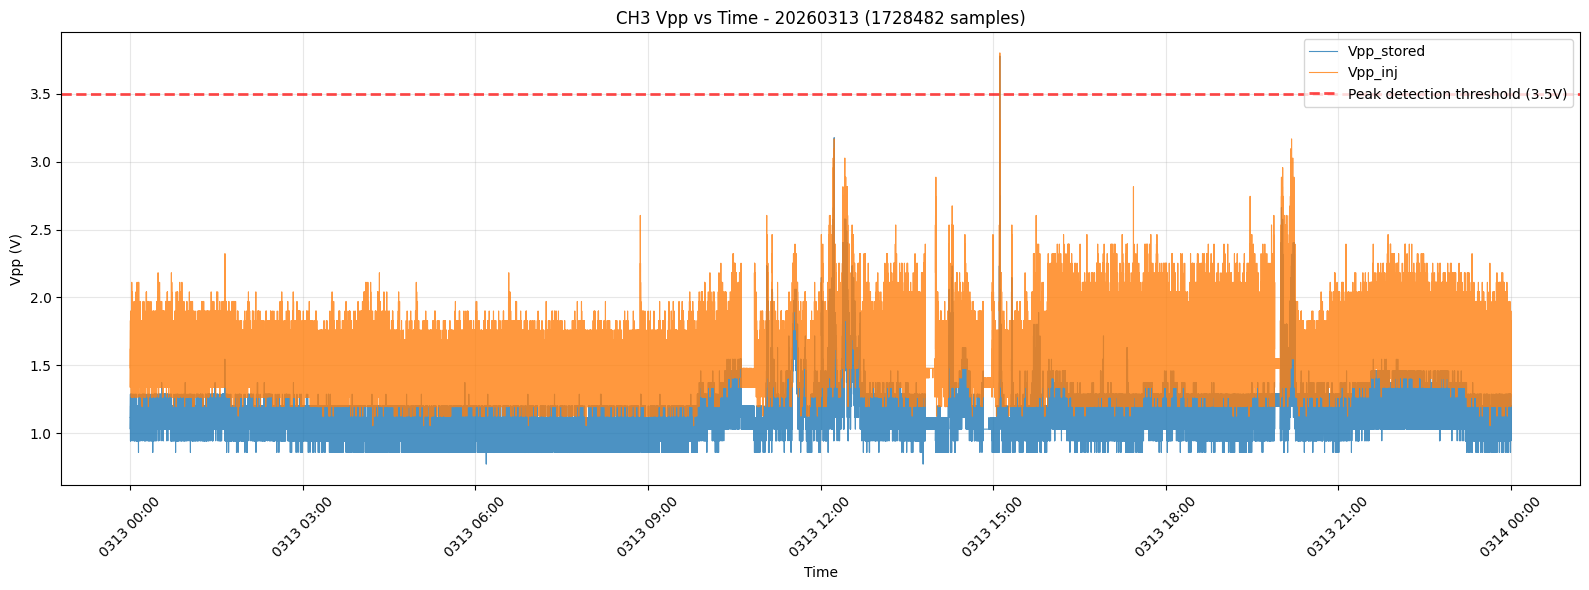

✓ Peak summary plot saved to: /Users/xylu/Desktop/Data/acoustic_vpp/summary/20260313_peak_summary_plot.png
✓ Stored peaks saved to: /Users/xylu/Desktop/Data/acoustic_vpp/summary/20260313_peaks_stored.csv
✓ Inj peaks saved to: /Users/xylu/Desktop/Data/acoustic_vpp/summary/20260313_peaks_inj.csv

✓ Folder '20260313' complete! Data saved to: /Users/xylu/Desktop/Data/acoustic_vpp/20260313

[9/12] Processing folder: 20260314
Found 288 total video file(s)
Processing all 288 file(s)

[1/288] 20260314_000000_n.mkv
  ✓ Vpp_stored: 0.859 - 1.288 V
  ✓ Vpp_inj: 1.196 - 1.971 V

[2/288] 20260314_000500_n.mkv
  ✓ Vpp_stored: 1.030 - 1.030 V
  ✓ Vpp_inj: 1.267 - 1.408 V

[3/288] 20260314_001000_n.mkv
  ✓ Vpp_stored: 1.030 - 1.030 V
  ✓ Vpp_inj: 1.337 - 1.408 V

[4/288] 20260314_001500_n.mkv
  ✓ Vpp_stored: 1.030 - 1.030 V
  ✓ Vpp_inj: 1.267 - 1.408 V

[5/288] 20260314_002000_n.mkv
  ✓ Vpp_stored: 0.859 - 1.288 V
  ✓ Vpp_inj: 1.126 - 2.604 V

[6/288] 20260314_002500_n.mkv
  ✓ Vpp_stored: 0.859 - 1.20

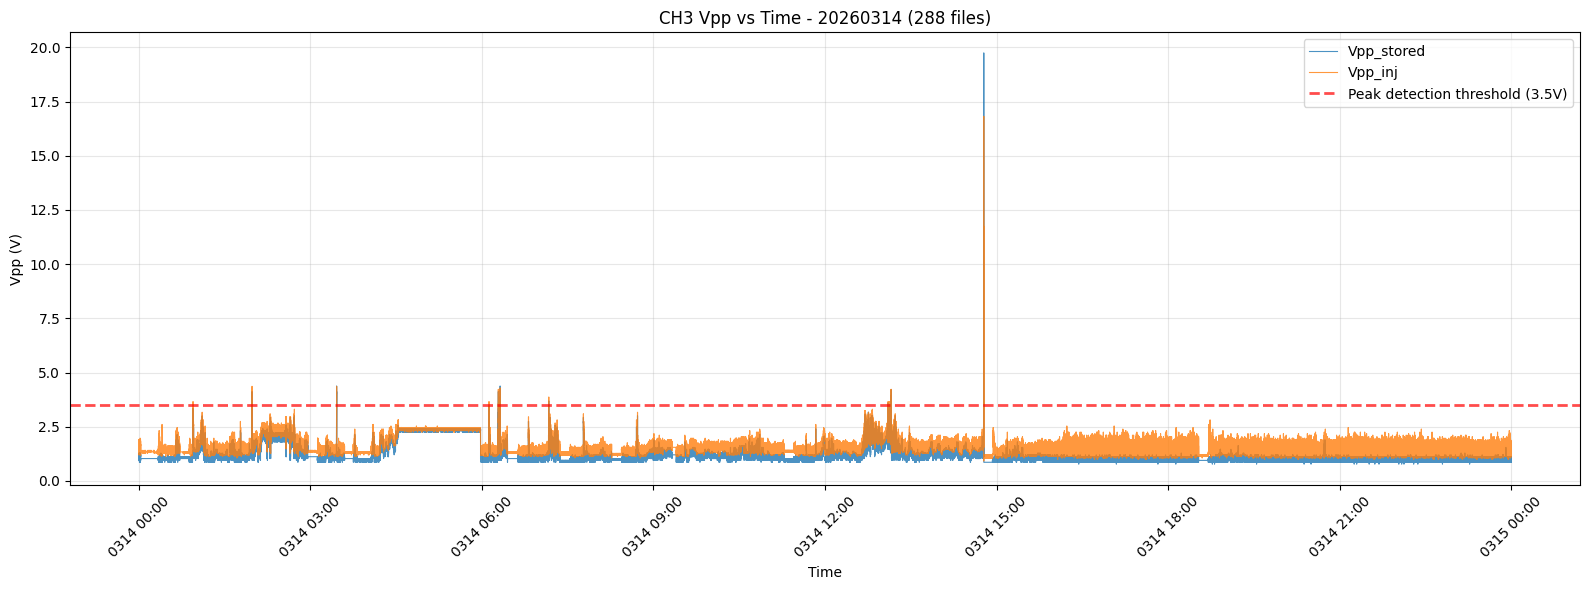


Found 20 STORED peaks with Vpp > 3.5 V
Found 28 INJ peaks with Vpp > 3.5 V


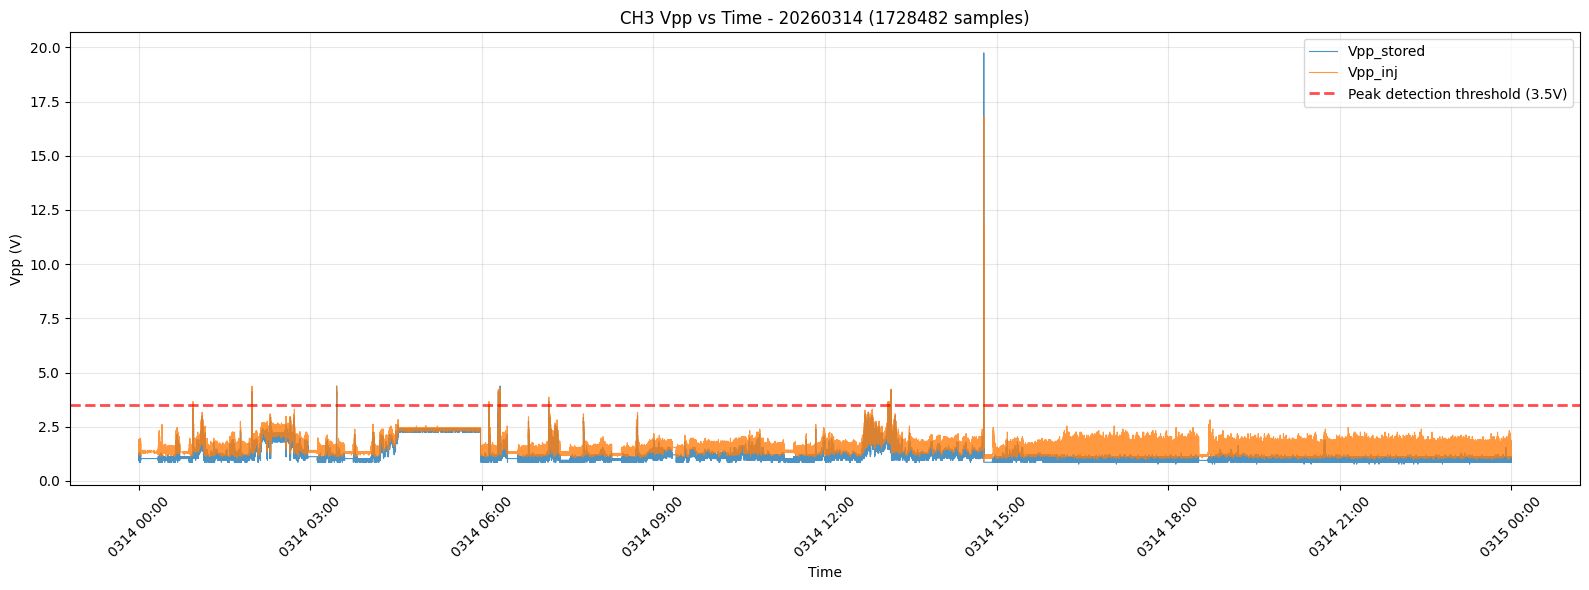

✓ Peak summary plot saved to: /Users/xylu/Desktop/Data/acoustic_vpp/summary/20260314_peak_summary_plot.png
✓ Stored peaks saved to: /Users/xylu/Desktop/Data/acoustic_vpp/summary/20260314_peaks_stored.csv
✓ Inj peaks saved to: /Users/xylu/Desktop/Data/acoustic_vpp/summary/20260314_peaks_inj.csv

✓ Folder '20260314' complete! Data saved to: /Users/xylu/Desktop/Data/acoustic_vpp/20260314

[10/12] Processing folder: 20260315
Found 288 total video file(s)
Processing all 288 file(s)

[1/288] 20260315_000000_n.mkv
  ✓ Vpp_stored: 0.859 - 1.202 V
  ✓ Vpp_inj: 1.056 - 2.252 V

[2/288] 20260315_000500_n.mkv
  ✓ Vpp_stored: 0.773 - 1.202 V
  ✓ Vpp_inj: 1.056 - 2.182 V

[3/288] 20260315_001000_n.mkv
  ✓ Vpp_stored: 0.859 - 1.116 V
  ✓ Vpp_inj: 1.056 - 2.252 V

[4/288] 20260315_001500_n.mkv
  ✓ Vpp_stored: 0.859 - 1.202 V
  ✓ Vpp_inj: 1.056 - 2.252 V

[5/288] 20260315_002000_n.mkv
  ✓ Vpp_stored: 0.859 - 1.202 V
  ✓ Vpp_inj: 1.056 - 2.111 V

[6/288] 20260315_002500_n.mkv
  ✓ Vpp_stored: 0.859 - 1.1

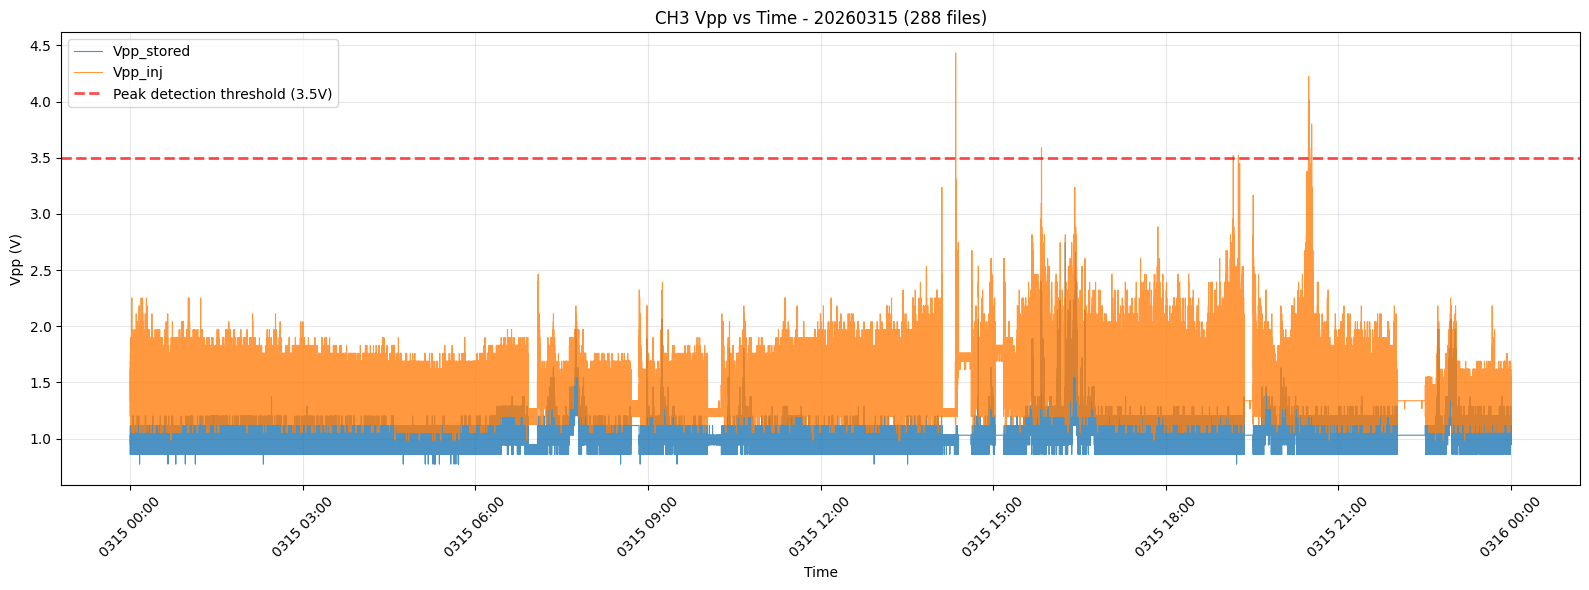


Found 0 STORED peaks with Vpp > 3.5 V
Found 11 INJ peaks with Vpp > 3.5 V


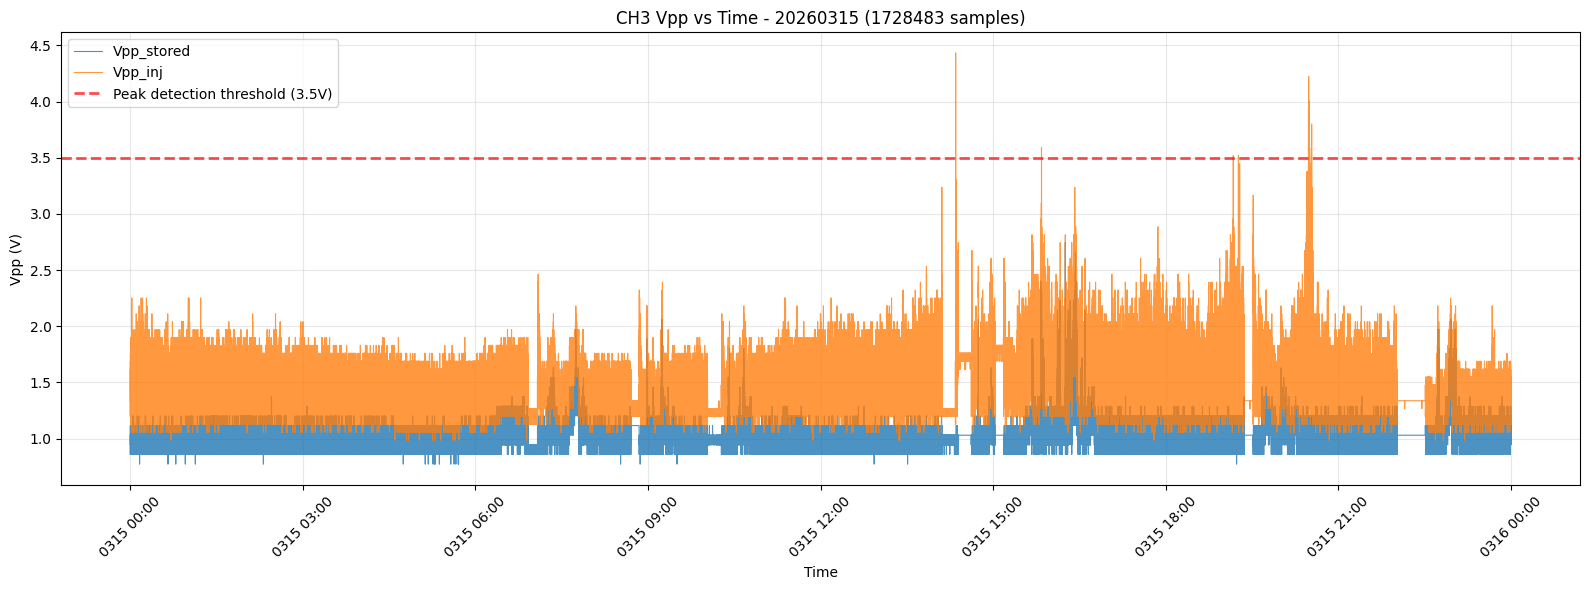

✓ Peak summary plot saved to: /Users/xylu/Desktop/Data/acoustic_vpp/summary/20260315_peak_summary_plot.png
✓ Inj peaks saved to: /Users/xylu/Desktop/Data/acoustic_vpp/summary/20260315_peaks_inj.csv

✓ Folder '20260315' complete! Data saved to: /Users/xylu/Desktop/Data/acoustic_vpp/20260315

[11/12] Processing folder: OLD
Found 0 total video file(s)
  ⚠ No .mkv files found, skipping folder

[12/12] Processing folder: System Volume Information
Found 0 total video file(s)
  ⚠ No .mkv files found, skipping folder

ALL FOLDERS PROCESSED!


In [2]:
# Get all subfolders in parent directory
subfolders = sorted([f.path for f in os.scandir(parent_folder) if f.is_dir()])
print(f"Found {len(subfolders)} folder(s) in: {parent_folder}")
print("="*60)

for folder_idx, video_folder in enumerate(subfolders):
    folder_name = os.path.basename(video_folder.rstrip('/'))
    print(f"\n{'='*60}")
    print(f"[{folder_idx + 1}/{len(subfolders)}] Processing folder: {folder_name}")
    print("="*60)
    
    # Find all .mkv files - try direct folder first
    mkv_files = sorted(glob.glob(os.path.join(video_folder, "*.mkv")))
    
    # If no files found, try RecData/0014 subdirectory
    if len(mkv_files) == 0:
        nested_folder = os.path.join(video_folder, "RecData", "0014")
        if os.path.isdir(nested_folder):
            mkv_files = sorted(glob.glob(os.path.join(nested_folder, "*.mkv")))
            if len(mkv_files) > 0:
                print(f"  → Found files in RecData/0014 subdirectory")
                video_folder = nested_folder
    
    print(f"Found {len(mkv_files)} total video file(s)")
    
    if len(mkv_files) == 0:
        print("  ⚠ No .mkv files found, skipping folder")
        continue
    
    # Create output folder based on video folder name
    output_folder = f"/Users/xylu/Desktop/Data/acoustic_vpp/{folder_name}"
    os.makedirs(output_folder, exist_ok=True)
    
    # Process files
    if max_files is None:
        mkv_files_to_process = mkv_files
        print(f"Processing all {len(mkv_files_to_process)} file(s)")
    else:
        mkv_files_to_process = mkv_files[:max_files]
        print(f"Processing {len(mkv_files_to_process)} file(s) (limited by max_files={max_files})")
    print("="*60)
    
    # Container for combined data
    all_time_datetime = []
    all_vpp_stored = []
    all_vpp_inj = []
    file_info = []
    
    for file_idx, file_path in enumerate(mkv_files_to_process):
        basename = os.path.basename(file_path)
        print(f"\n[{file_idx + 1}/{len(mkv_files_to_process)}] {basename}")
        
        # Extract start time
        start_dt = extract_datetime_from_filename(basename)
        if start_dt is None:
            print(f"  ⚠ Skipped: Could not extract datetime")
            continue
        
        # Compute Vpp series for both regions
        try:
            time_s, vpp_stored, vpp_inj = compute_vpp_series_for_file(
                file_path,
                v_div=v_div,
                fps=fps,
                threshold_stored=profile_threshold_stored,
                threshold_inj=profile_threshold_inj,
                split_x=inj_time_px,
                grid_height_px_stored=grid_height_px_stored,
                grid_height_px_inj=grid_height_px_inj,
            )
            
            # Convert time to datetime
            time_datetime_data = np.array([start_dt + timedelta(seconds=t) for t in time_s])
            
            # Accumulate data
            all_time_datetime.extend(time_datetime_data)
            all_vpp_stored.extend(vpp_stored)
            all_vpp_inj.extend(vpp_inj)
            
            # Create DataFrame for individual file
            df = pd.DataFrame({
                'time_datetime': time_datetime_data.astype(str),
                'time_seconds': time_s,
                'vpp_stored': vpp_stored,
                'vpp_inj': vpp_inj
            })
            
            # Save individual CSV
            csv_filename = basename.replace('.mkv', '_vpp.csv')
            csv_filepath = os.path.join(output_folder, csv_filename)
            df.to_csv(csv_filepath, index=False)
            
            vpp_stored_min, vpp_stored_max = np.nanmin(vpp_stored), np.nanmax(vpp_stored)
            vpp_inj_min, vpp_inj_max = np.nanmin(vpp_inj), np.nanmax(vpp_inj)
            print(f"  ✓ Vpp_stored: {vpp_stored_min:.3f} - {vpp_stored_max:.3f} V")
            print(f"  ✓ Vpp_inj: {vpp_inj_min:.3f} - {vpp_inj_max:.3f} V")
            file_info.append((basename, start_dt, vpp_stored_min, vpp_stored_max, vpp_inj_min, vpp_inj_max))
            
        except Exception as e:
            print(f"  ✗ Error: {str(e)}")
    
    # Convert to arrays
    all_time_datetime = np.array(all_time_datetime)
    all_vpp_stored = np.array(all_vpp_stored)
    all_vpp_inj = np.array(all_vpp_inj)
    
    print("\n" + "="*60)
    print(f"COMBINED DATA: {len(all_vpp_stored)} samples")
    if len(all_vpp_stored) > 0:
        print(f"Vpp_stored: {np.nanmin(all_vpp_stored):.3f} - {np.nanmax(all_vpp_stored):.3f} V")
        print(f"Vpp_inj: {np.nanmin(all_vpp_inj):.3f} - {np.nanmax(all_vpp_inj):.3f} V")
        print(f"Time span: {all_time_datetime[0]} to {all_time_datetime[-1]}")
    print("="*60)
    
    # Plot combined Vpp vs time
    if len(all_vpp_stored) > 0:
        fig, ax = plt.subplots(figsize=(16, 6))
        ax.plot(all_time_datetime, all_vpp_stored, linewidth=0.8, label='Vpp_stored', alpha=0.8)
        ax.plot(all_time_datetime, all_vpp_inj, linewidth=0.8, label='Vpp_inj', alpha=0.8)
        ax.axhline(y=peak_threshold, color='r', linestyle='--', linewidth=2, alpha=0.7, label=f'Peak detection threshold ({peak_threshold}V)')
        ax.set_title(f"CH3 Vpp vs Time - {folder_name} ({len(mkv_files_to_process)} files)")
        ax.set_xlabel("Time")
        ax.set_ylabel("Vpp (V)")
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%m%d %H:%M'))
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
        
        # Find peaks in both signals
        vpp_peaks_stored, _ = find_peaks(all_vpp_stored, height=peak_threshold, distance=20)
        vpp_peaks_inj, _ = find_peaks(all_vpp_inj, height=peak_threshold, distance=20)
        print(f"\nFound {len(vpp_peaks_stored)} STORED peaks with Vpp > {peak_threshold} V")
        print(f"Found {len(vpp_peaks_inj)} INJ peaks with Vpp > {peak_threshold} V")
        print("="*60)
        
        # Save peak summaries and figure
        summary_folder = os.path.abspath(os.path.join(output_folder, '../summary/'))
        os.makedirs(summary_folder, exist_ok=True)
        
        # Create summary figure with both signals
        fig, ax = plt.subplots(figsize=(16, 6))
        ax.plot(all_time_datetime, all_vpp_stored, linewidth=0.8, label='Vpp_stored', alpha=0.8)
        ax.plot(all_time_datetime, all_vpp_inj, linewidth=0.8, label='Vpp_inj', alpha=0.8)
        ax.axhline(y=peak_threshold, color='r', linestyle='--', linewidth=2, alpha=0.7, label=f'Peak detection threshold ({peak_threshold}V)')
        ax.set_title(f"CH3 Vpp vs Time - {folder_name} ({len(all_vpp_stored)} samples)")
        ax.set_xlabel("Time")
        ax.set_ylabel("Vpp (V)")
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%m%d %H:%M'))
        plt.xticks(rotation=45)
        plt.tight_layout()
        plot_path = os.path.join(summary_folder, f"{folder_name}_peak_summary_plot.png")
        plt.savefig(plot_path, dpi=100, bbox_inches='tight')
        plt.show()
        print(f"✓ Peak summary plot saved to: {plot_path}")
        
        # Save STORED peaks
        if len(vpp_peaks_stored) > 0:
            stored_peak_data = []
            for peak_idx, sample_idx in enumerate(vpp_peaks_stored):
                peak_time = all_time_datetime[sample_idx]
                vpp_stored_val = all_vpp_stored[sample_idx]
                vpp_inj_val = all_vpp_inj[sample_idx]
                stored_peak_data.append({
                    'peak_number': peak_idx + 1,
                    'sample_idx': int(sample_idx),
                    'time_datetime': peak_time.strftime('%Y-%m-%d %H:%M:%S.%f')[:-3],
                    'vpp_stored_volts': float(vpp_stored_val),
                    'vpp_inj_volts': float(vpp_inj_val)
                })
            stored_df = pd.DataFrame(stored_peak_data)
            stored_csv_path = os.path.join(summary_folder, f"{folder_name}_peaks_stored.csv")
            stored_df.to_csv(stored_csv_path, index=False)
            print(f"✓ Stored peaks saved to: {stored_csv_path}")
        
        # Save INJ peaks
        if len(vpp_peaks_inj) > 0:
            inj_peak_data = []
            for peak_idx, sample_idx in enumerate(vpp_peaks_inj):
                peak_time = all_time_datetime[sample_idx]
                vpp_stored_val = all_vpp_stored[sample_idx]
                vpp_inj_val = all_vpp_inj[sample_idx]
                inj_peak_data.append({
                    'peak_number': peak_idx + 1,
                    'sample_idx': int(sample_idx),
                    'time_datetime': peak_time.strftime('%Y-%m-%d %H:%M:%S.%f')[:-3],
                    'vpp_inj_volts': float(vpp_inj_val),
                    'vpp_stored_volts': float(vpp_stored_val)
                })
            inj_df = pd.DataFrame(inj_peak_data)
            inj_csv_path = os.path.join(summary_folder, f"{folder_name}_peaks_inj.csv")
            inj_df.to_csv(inj_csv_path, index=False)
            print(f"✓ Inj peaks saved to: {inj_csv_path}")
    
    print(f"\n✓ Folder '{folder_name}' complete! Data saved to: {output_folder}")

print("\n" + "="*60)
print("ALL FOLDERS PROCESSED!")
print("="*60)